In [2]:
# --- Cell 1: Setup and load data ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# If using the Mall Customer dataset from Kaggle:
# Upload it via the Colab file icon, or mount Drive like you did for Project 2
df = pd.read_csv('Mall_Customers.csv')  # adjust filename/path as needed

print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# --- Cell 2: Quick sanity check ---
print(df.info())
print(df.isnull().sum())        # confirm no missing values
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.00000

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numeric features (drop CustomerID and Gender for now)
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("First 5 scaled rows:")
print(scaled_features[:5])

# PCA to 2 components
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

First 5 scaled rows:
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]

Explained variance ratio: [0.44266167 0.33308378]
Total variance captured: 0.7757454566976747


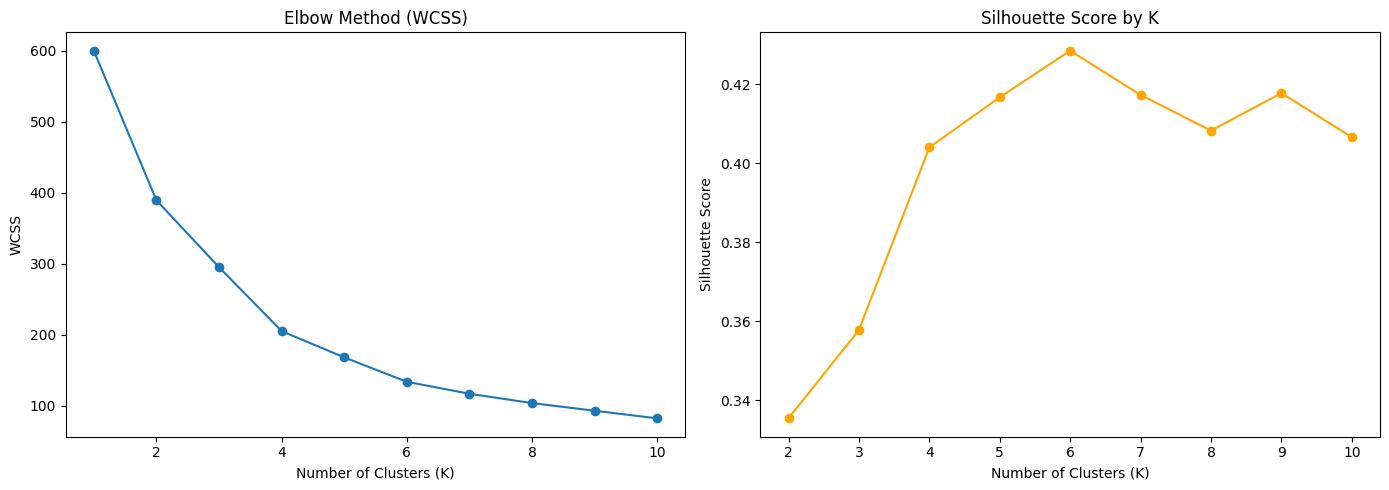

WCSS values: [599.9999999999999, 389.38618895643714, 295.21224615554877, 205.22514747675913, 168.2475801755683, 133.86842085478855, 117.01155455889815, 103.87329152383714, 93.0928911004172, 82.38515364526597]
Silhouette scores (K=2..10): [np.float64(0.33547192894004574), np.float64(0.357793388710272), np.float64(0.4039582785148566), np.float64(0.41664341513732767), np.float64(0.4284167762892593), np.float64(0.417231894954916), np.float64(0.4082067042807375), np.float64(0.41769250624076476), np.float64(0.40655411010117015)]


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Elbow Method: WCSS for K = 1 to 10 ---
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(scaled_features)
    wcss.append(km.inertia_)

# --- Silhouette Score: only defined for K >= 2 ---
sil_scores = []
K_range_sil = range(2, 11)
for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    sil_scores.append(silhouette_score(scaled_features, labels))

# --- Plot both side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, wcss, marker='o')
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')

axes[1].plot(K_range_sil, sil_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("WCSS values:", wcss)
print("Silhouette scores (K=2..10):", sil_scores)

Cluster centroids in real-world units:
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        56.3                54.3                    49.1
1        26.8                57.1                    48.1
2        41.9                88.9                    17.0
3        32.7                86.5                    82.1
4        25.0                25.3                    77.6
5        45.5                26.3                    19.4

Cluster sizes:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

Gender split per cluster:
Gender   Female  Male
Cluster              
0          58.0  42.0
1          64.0  36.0
2          42.0  58.0
3          54.0  46.0
4          57.0  43.0
5          62.0  38.0


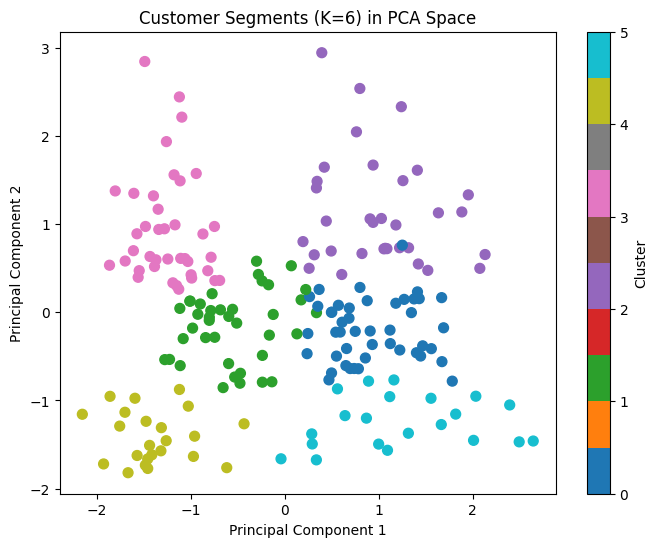

In [8]:
# --- Final K-Means fit with K=6 ---
optimal_k = 6
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_features)

df['Cluster'] = cluster_labels

# --- Reverse-engineer centroids back to real-world units ---
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(centroids_original, columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
centroid_df.index.name = 'Cluster'
print("Cluster centroids in real-world units:")
print(centroid_df.round(1))

# --- Cluster sizes and gender split ---
print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index())

print("\nGender split per cluster:")
print(pd.crosstab(df['Cluster'], df['Gender'], normalize='index').round(2) * 100)

# --- Visualize in 2D PCA space, colored by cluster ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_features[:,0], pca_features[:,1], c=cluster_labels, cmap='tab10', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Customer Segments (K={optimal_k}) in PCA Space')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [9]:
persona_map = {
    0: 'Mature Steady Spenders',
    1: 'Young Average Shoppers',
    2: 'Affluent Conservatives',
    3: 'High-Value Trendsetters',
    4: 'Budget-Conscious Explorers',
    5: 'Conservative Minimizers'
}
df['Persona'] = df['Cluster'].map(persona_map)
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Persona
0,1,Male,19,15,39,4,Budget-Conscious Explorers
1,2,Male,21,15,81,4,Budget-Conscious Explorers
2,3,Female,20,16,6,5,Conservative Minimizers
3,4,Female,23,16,77,4,Budget-Conscious Explorers
4,5,Female,31,17,40,5,Conservative Minimizers
5,6,Female,22,17,76,4,Budget-Conscious Explorers
6,7,Female,35,18,6,5,Conservative Minimizers
7,8,Female,23,18,94,4,Budget-Conscious Explorers
8,9,Male,64,19,3,5,Conservative Minimizers
9,10,Female,30,19,72,4,Budget-Conscious Explorers
